<a href="https://colab.research.google.com/github/parsamirzakhani/machinelearnign_project_parsa_mahan/blob/main/notebook/pneumonia_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q medmnist torch torchvision scikit-learn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.2 MB/s eta 0:00:00


In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, matthews_corrcoef, roc_curve, precision_recall_curve)

SEED         = 42
IMG_SIZE     = 112
BATCH_SIZE   = 64
EPOCHS       = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 8

DATA_ROOT   = "data"
ART_DIR     = "artifacts"
FIG_DIR     = os.path.join(ART_DIR, "figures")
TAB_DIR     = os.path.join(ART_DIR, "tables")
for d in (DATA_ROOT, ART_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 9})

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("device:", DEVICE, "| input size:", IMG_SIZE)

device: cuda | input size: 112


In [3]:
from medmnist import PneumoniaMNIST, INFO

info = INFO["pneumoniamnist"]
CLASS_NAMES = [info["label"]["0"], info["label"]["1"]]

raw = {}
for split in ["train", "val", "test"]:
    ds = PneumoniaMNIST(split=split, download=True, root=DATA_ROOT)
    raw[split] = (ds.imgs.astype(np.uint8), ds.labels.reshape(-1).astype(np.int64))

rows = []
for s, (x, y) in raw.items():
    rows.append({"Split": s, "Images": len(y),
                 "Normal (0)": int((y == 0).sum()),
                 "Pneumonia (1)": int((y == 1).sum()),
                 "Pneumonia %": round(100.0 * (y == 1).mean(), 2)})
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(TAB_DIR, "tab01_dataset_summary.csv"), index=False)
print("classes:", CLASS_NAMES)
summary

100%|██████████| 4.17M/4.17M [00:06<00:00, 616kB/s]


classes: ['normal', 'pneumonia']


,Split,Images,Normal (0),Pneumonia (1),Pneumonia %
0,train,4708,1214,3494,74.21
1,val,524,135,389,74.24
2,test,624,234,390,62.50


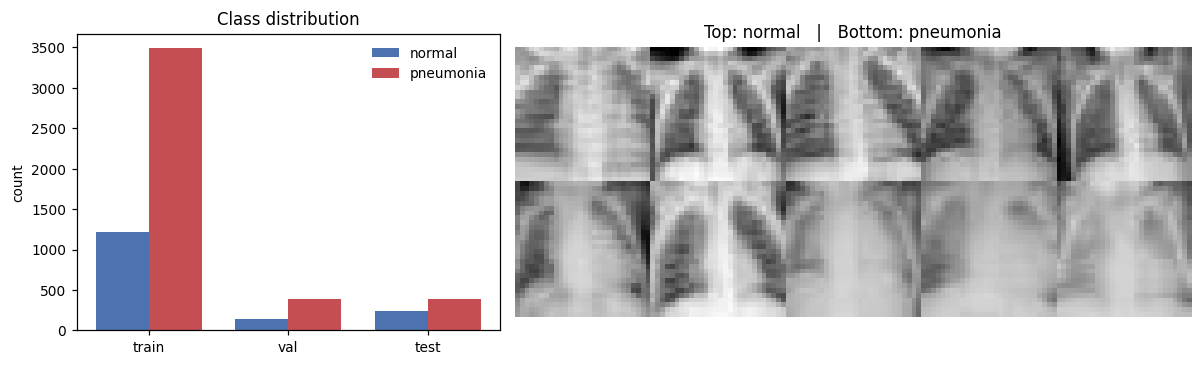

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})

width = 0.38; idx = np.arange(3)
neg = [int((raw[s][1] == 0).sum()) for s in ["train", "val", "test"]]
pos = [int((raw[s][1] == 1).sum()) for s in ["train", "val", "test"]]
axes[0].bar(idx - width/2, neg, width, label=CLASS_NAMES[0], color="#4C72B0")
axes[0].bar(idx + width/2, pos, width, label=CLASS_NAMES[1], color="#C44E52")
axes[0].set_xticks(idx); axes[0].set_xticklabels(["train", "val", "test"])
axes[0].set_ylabel("count"); axes[0].set_title("Class distribution")
axes[0].legend(frameon=False)

axes[1].axis("off")
xte, yte = raw["test"]
sel = np.concatenate([np.where(yte == 0)[0][:5], np.where(yte == 1)[0][:5]])
grid = np.zeros((2 * 28, 5 * 28), dtype=np.uint8)
for k, i in enumerate(sel):
    r, c = divmod(k, 5)
    grid[r*28:(r+1)*28, c*28:(c+1)*28] = xte[i]
axes[1].imshow(grid, cmap="gray")
axes[1].set_title("Top: normal   |   Bottom: pneumonia")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig01_dataset_overview.png"), bbox_inches="tight")
plt.show()

In [5]:
class PneumoniaDataset(Dataset):
    def __init__(self, images, labels, transform=None, size=IMG_SIZE):
        x = torch.from_numpy(images.astype(np.float32) / 255.0).unsqueeze(1)
        self.x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
        self.y = torch.from_numpy(labels.astype(np.float32)).unsqueeze(1)
        self.transform = transform
    def __len__(self): return self.x.shape[0]
    def __getitem__(self, i):
        img = self.x[i]
        if self.transform is not None:
            img = self.transform(img)
        return img, self.y[i]

train_tf = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0), antialias=True),
])

datasets = {
    "train": PneumoniaDataset(*raw["train"], transform=train_tf),
    "val":   PneumoniaDataset(*raw["val"],   transform=None),
    "test":  PneumoniaDataset(*raw["test"],  transform=None),
}
loaders = {
    "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True),
    "val":   DataLoader(datasets["val"],   batch_size=BATCH_SIZE, shuffle=False),
    "test":  DataLoader(datasets["test"],  batch_size=BATCH_SIZE, shuffle=False),
}
print("batches:", {k: len(v) for k, v in loaders.items()})

batches: {'train': 74, 'val': 9, 'test': 10}


In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden), nn.ReLU(inplace=True), nn.Linear(hidden, channels)
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1).view(b, c))
        mx  = self.mlp(F.adaptive_max_pool2d(x, 1).view(b, c))
        w = torch.sigmoid(avg + mx).view(b, c, 1, 1)
        return x * w

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        w = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * w

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8, kernel_size=3):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.spatial(self.channel(x))

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class PneumoniaCNN(nn.Module):
    def __init__(self, use_attention=False, dropout=0.3):
        super().__init__()
        self.use_attention = use_attention
        self.block1 = ConvBlock(1, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.att = CBAM(256) if use_attention else nn.Identity()
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(256, 1)
        )
    def forward(self, x):
        x = self.pool(self.block1(x))
        x = self.pool(self.block2(x))
        x = self.pool(self.block3(x))
        x = self.pool(self.block4(x))
        x = self.att(x)
        return self.head(x)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("CNN params:          ", f"{count_params(PneumoniaCNN(False)):,}")
print("CNN + CBAM params:   ", f"{count_params(PneumoniaCNN(True)):,}")

CNN params:           1,173,857
CNN + CBAM params:    1,190,547


In [8]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "Threshold": round(float(threshold), 3),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }

def round_metrics(d, nd=4):
    return {k: (round(v, nd) if isinstance(v, float) else v) for k, v in d.items()}

In [9]:
@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs, labels = [], []
    for x, y in loader:
        p = torch.sigmoid(model(x.to(DEVICE))).cpu().numpy().ravel()
        probs.append(p); labels.append(y.numpy().ravel())
    return np.concatenate(labels), np.concatenate(probs)

def train_model(model, tag, epochs=EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    criterion = nn.BCEWithLogitsLoss()
    history, best, best_state, bad = [], -1.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        run, n, tp, ty = 0.0, 0, [], []
        for x, y in loaders["train"]:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward(); opt.step()
            run += loss.item() * x.size(0); n += x.size(0)
            tp.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
            ty.append(y.detach().cpu().numpy().ravel())
        tp, ty = np.concatenate(tp), np.concatenate(ty)

        vrun, vn = 0.0, 0
        model.eval()
        with torch.no_grad():
            for x, y in loaders["val"]:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vrun += criterion(model(x), y).item() * x.size(0); vn += x.size(0)
        vy, vp = predict_probs(model, loaders["val"])
        val_auc = roc_auc_score(vy, vp)
        sched.step(val_auc)

        history.append({
            "epoch": epoch,
            "train_loss": run / n, "val_loss": vrun / vn,
            "train_acc": accuracy_score(ty, (tp >= 0.5).astype(int)),
            "val_acc": accuracy_score(vy, (vp >= 0.5).astype(int)),
            "train_auc": roc_auc_score(ty, tp), "val_auc": val_auc,
        })
        print(f"[{tag}] ep {epoch:02d}  train_loss {run/n:.4f}  val_loss {vrun/vn:.4f}  "
              f"val_acc {history[-1]['val_acc']:.4f}  val_auc {val_auc:.4f}")

        if val_auc > best + 1e-5:
            best, best_state, bad = val_auc, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
        if bad >= patience:
            print(f"[{tag}] early stopping at epoch {epoch}"); break

    model.load_state_dict(best_state)
    hist = pd.DataFrame(history)
    hist.to_csv(os.path.join(TAB_DIR, f"history_{tag}.csv"), index=False)
    print(f"[{tag}] best val ROC-AUC: {best:.4f}")
    return model, hist

In [10]:
set_seed()
model_a = PneumoniaCNN(use_attention=False)
t0 = time.time()
model_a, hist_a = train_model(model_a, "cnn")
time_a = time.time() - t0
torch.save(model_a.state_dict(), os.path.join(ART_DIR, "cnn.pt"))
print("train time (s):", round(time_a, 1))

[cnn] ep 01  train_loss 0.2358  val_loss 3.3294  val_acc 0.3359  val_auc 0.9263
[cnn] ep 02  train_loss 0.1655  val_loss 0.1453  val_acc 0.9561  val_auc 0.9861
[cnn] ep 03  train_loss 0.1395  val_loss 0.3770  val_acc 0.8130  val_auc 0.8840
[cnn] ep 04  train_loss 0.1295  val_loss 0.1414  val_acc 0.9542  val_auc 0.9836
[cnn] ep 05  train_loss 0.1309  val_loss 0.3863  val_acc 0.8321  val_auc 0.9880
[cnn] ep 06  train_loss 0.1099  val_loss 0.3132  val_acc 0.8645  val_auc 0.9944
[cnn] ep 07  train_loss 0.1150  val_loss 0.1382  val_acc 0.9466  val_auc 0.9901
[cnn] ep 08  train_loss 0.1021  val_loss 0.4398  val_acc 0.8416  val_auc 0.9894
[cnn] ep 09  train_loss 0.0988  val_loss 0.1075  val_acc 0.9637  val_auc 0.9904
[cnn] ep 10  train_loss 0.1009  val_loss 0.1132  val_acc 0.9485  val_auc 0.9909
[cnn] ep 11  train_loss 0.0892  val_loss 0.3762  val_acc 0.8607  val_auc 0.9926
[cnn] ep 12  train_loss 0.0722  val_loss 0.1068  val_acc 0.9599  val_auc 0.9937
[cnn] ep 13  train_loss 0.0794  val_loss

In [11]:
set_seed()
model_b = PneumoniaCNN(use_attention=True)
t0 = time.time()
model_b, hist_b = train_model(model_b, "cnn_cbam")
time_b = time.time() - t0
torch.save(model_b.state_dict(), os.path.join(ART_DIR, "cnn_cbam.pt"))
print("train time (s):", round(time_b, 1))

[cnn_cbam] ep 01  train_loss 0.2329  val_loss 0.4469  val_acc 0.7996  val_auc 0.9337
[cnn_cbam] ep 02  train_loss 0.1704  val_loss 0.1654  val_acc 0.9179  val_auc 0.9821
[cnn_cbam] ep 03  train_loss 0.1400  val_loss 0.5868  val_acc 0.7481  val_auc 0.9763
[cnn_cbam] ep 04  train_loss 0.1263  val_loss 0.1453  val_acc 0.9427  val_auc 0.9888
[cnn_cbam] ep 05  train_loss 0.1199  val_loss 4.6558  val_acc 0.3187  val_auc 0.9032
[cnn_cbam] ep 06  train_loss 0.1105  val_loss 0.8927  val_acc 0.6947  val_auc 0.9826
[cnn_cbam] ep 07  train_loss 0.1072  val_loss 0.1070  val_acc 0.9580  val_auc 0.9909
[cnn_cbam] ep 08  train_loss 0.1002  val_loss 0.1038  val_acc 0.9656  val_auc 0.9925
[cnn_cbam] ep 09  train_loss 0.0962  val_loss 0.2966  val_acc 0.8950  val_auc 0.9766
[cnn_cbam] ep 10  train_loss 0.1024  val_loss 0.0993  val_acc 0.9618  val_auc 0.9948
[cnn_cbam] ep 11  train_loss 0.0956  val_loss 0.0771  val_acc 0.9771  val_auc 0.9950
[cnn_cbam] ep 12  train_loss 0.0842  val_loss 0.1448  val_acc 0.9

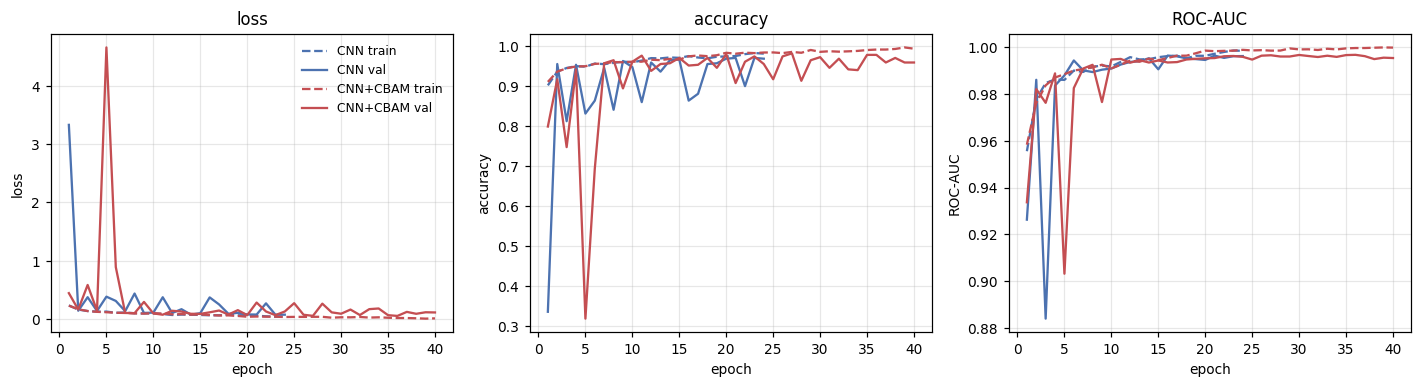

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [("loss", "train_loss", "val_loss"),
          ("accuracy", "train_acc", "val_acc"),
          ("ROC-AUC", "train_auc", "val_auc")]
for ax, (name, tr, va) in zip(axes, panels):
    ax.plot(hist_a["epoch"], hist_a[tr], color="#4C72B0", ls="--", label="CNN train")
    ax.plot(hist_a["epoch"], hist_a[va], color="#4C72B0", label="CNN val")
    ax.plot(hist_b["epoch"], hist_b[tr], color="#C44E52", ls="--", label="CNN+CBAM train")
    ax.plot(hist_b["epoch"], hist_b[va], color="#C44E52", label="CNN+CBAM val")
    ax.set_xlabel("epoch"); ax.set_ylabel(name); ax.set_title(name); ax.grid(alpha=0.3)
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig02_training_curves.png"), bbox_inches="tight")
plt.show()

In [13]:
def best_threshold_f1(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1[:-1]))
    return float(thr[idx])

val_a = predict_probs(model_a, loaders["val"])
val_b = predict_probs(model_b, loaders["val"])
thr_a = best_threshold_f1(*val_a)
thr_b = best_threshold_f1(*val_b)
print("thresholds:", round(thr_a, 3), round(thr_b, 3))

thresholds: 0.006 0.408


In [14]:
test_a = predict_probs(model_a, loaders["test"])
test_b = predict_probs(model_b, loaders["test"])

results = pd.DataFrame([
    {"Model": "CNN",        "Setting": "thr 0.5",   **round_metrics(compute_metrics(*test_a, 0.5))},
    {"Model": "CNN + CBAM", "Setting": "thr 0.5",   **round_metrics(compute_metrics(*test_b, 0.5))},
    {"Model": "CNN",        "Setting": "tuned thr", **round_metrics(compute_metrics(*test_a, thr_a))},
    {"Model": "CNN + CBAM", "Setting": "tuned thr", **round_metrics(compute_metrics(*test_b, thr_b))},
])
results.to_csv(os.path.join(TAB_DIR, "tab02_test_metrics.csv"), index=False)
results.T

,0,1,2,3
Model,CNN,CNN + CBAM,CNN,CNN + CBAM
Setting,thr 0.5,thr 0.5,tuned thr,tuned thr
Threshold,0.5,0.5,0.006,0.408
Accuracy,0.9038,0.8974,0.8686,0.8846
Balanced accuracy,0.912,0.8641,0.8282,0.847
Sensitivity,0.8795,0.9974,0.9897,0.9974
Specificity,0.9444,0.7308,0.6667,0.6966
Precision,0.9635,0.8606,0.8319,0.8457
F1,0.9196,0.924,0.904,0.9153
MCC,0.8058,0.789,0.7278,0.7633


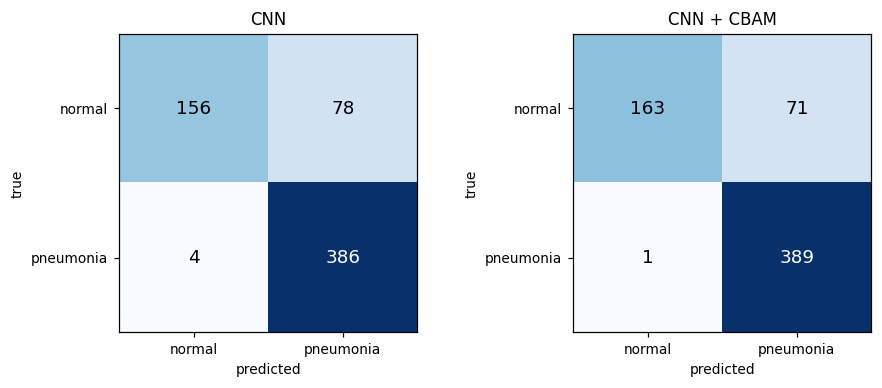

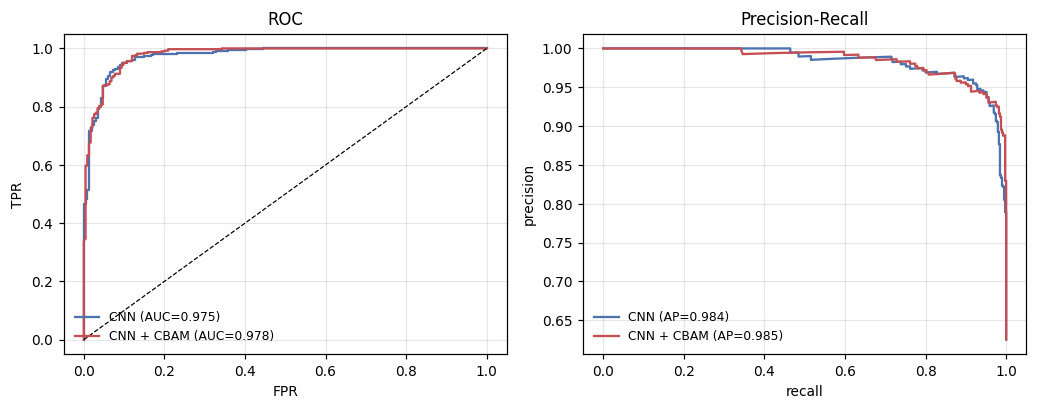

In [15]:
def plot_cm(ax, y_true, y_prob, thr, title):
    cm = confusion_matrix(y_true, (y_prob >= thr).astype(int), labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6))
plot_cm(axes[0], *test_a, thr_a, "CNN")
plot_cm(axes[1], *test_b, thr_b, "CNN + CBAM")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig03_confusion_matrices.png"), bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for (y, p), name, color in [(test_a, "CNN", "#4C72B0"), (test_b, "CNN + CBAM", "#C44E52")]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc_score(y, p):.3f})")
    prec, rec, _ = precision_recall_curve(y, p)
    axes[1].plot(rec, prec, color=color, label=f"{name} (AP={average_precision_score(y, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-Recall")
for ax in axes: ax.grid(alpha=0.3); ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig04_roc_pr_curves.png"), bbox_inches="tight")
plt.show()

In [16]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None; self.grads = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o): self.acts = o.detach()
    def _save_grad(self, m, gi, go): self.grads = go[0].detach()
    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x)
        logit.sum().backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, float(torch.sigmoid(logit).item())

cam_engine = GradCAM(model_b, model_b.block4)

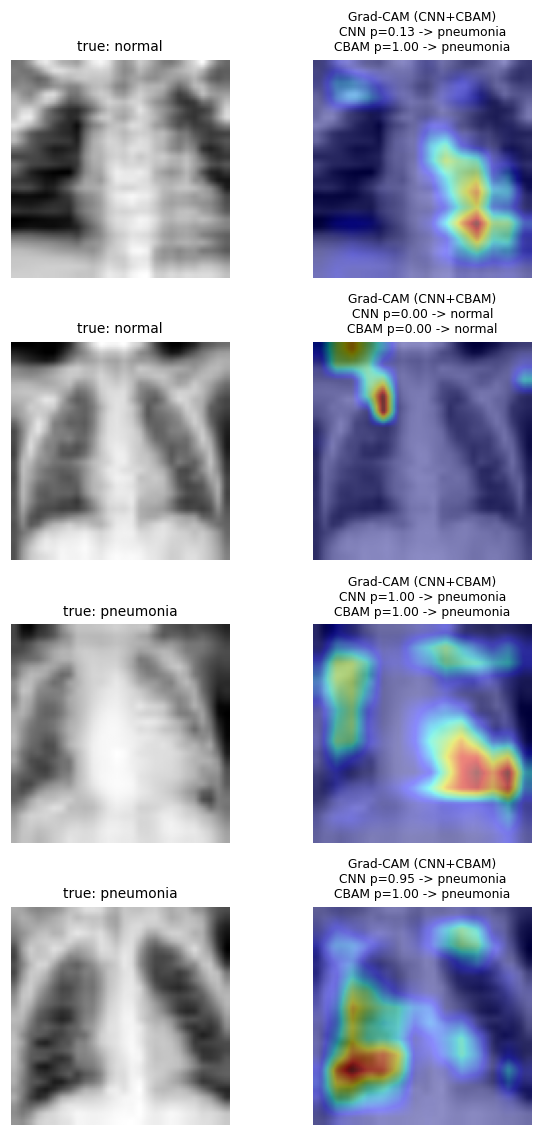

,Test idx,True,CNN prob,CNN pred,CBAM prob,CBAM pred
0,1,normal,0.1297,pneumonia,0.9980,pneumonia
1,3,normal,0.0000,normal,0.0002,normal
2,0,pneumonia,0.9992,pneumonia,1.0000,pneumonia
3,2,pneumonia,0.9492,pneumonia,0.9998,pneumonia


In [17]:
yte = datasets["test"].y.numpy().ravel().astype(int)
picks = list(np.where(yte == 0)[0][:2]) + list(np.where(yte == 1)[0][:2])

fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.6 * len(picks)))
for r, i in enumerate(picks):
    img = datasets["test"].x[i:i+1].to(DEVICE)
    cam, prob = cam_engine(img)
    im = datasets["test"].x[i, 0].numpy()
    pa, pb = test_a[1][i], test_b[1][i]
    axes[r, 0].imshow(im, cmap="gray"); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"true: {CLASS_NAMES[yte[i]]}", fontsize=9)
    axes[r, 1].imshow(im, cmap="gray")
    axes[r, 1].imshow(cam, cmap="jet", alpha=0.45)
    axes[r, 1].axis("off")
    axes[r, 1].set_title(f"Grad-CAM (CNN+CBAM)\nCNN p={pa:.2f} -> {CLASS_NAMES[int(pa>=thr_a)]}\nCBAM p={pb:.2f} -> {CLASS_NAMES[int(pb>=thr_b)]}", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig05_gradcam_examples.png"), bbox_inches="tight")
plt.show()

example_table = pd.DataFrame([{
    "Test idx": int(i),
    "True": CLASS_NAMES[yte[i]],
    "CNN prob": round(float(test_a[1][i]), 4),
    "CNN pred": CLASS_NAMES[int(test_a[1][i] >= thr_a)],
    "CBAM prob": round(float(test_b[1][i]), 4),
    "CBAM pred": CLASS_NAMES[int(test_b[1][i] >= thr_b)],
} for i in picks])
example_table.to_csv(os.path.join(TAB_DIR, "tab03_inference_examples.csv"), index=False)
example_table

In [18]:
sel = pd.DataFrame([
    {"Model": "CNN",        "val_ROC_AUC": roc_auc_score(*val_a),
     "val_bal_acc": balanced_accuracy_score(val_a[0], (val_a[1] >= thr_a).astype(int))},
    {"Model": "CNN + CBAM", "val_ROC_AUC": roc_auc_score(*val_b),
     "val_bal_acc": balanced_accuracy_score(val_b[0], (val_b[1] >= thr_b).astype(int))},
]).sort_values(["val_ROC_AUC", "val_bal_acc"], ascending=False).reset_index(drop=True)
print(sel)
best = sel.loc[0, "Model"]
print("selected:", best)

if best == "CNN":
    bundle_state = model_a.state_dict(); use_attention = False
    test_metrics = round_metrics(compute_metrics(*test_a, thr_a)); threshold = thr_a
else:
    bundle_state = model_b.state_dict(); use_attention = True
    test_metrics = round_metrics(compute_metrics(*test_b, thr_b)); threshold = thr_b

bundle = {
    "model_name": best,
    "use_attention": use_attention,
    "state_dict": bundle_state,
    "threshold": float(threshold),
    "class_names": CLASS_NAMES,
    "input_size": [1, IMG_SIZE, IMG_SIZE],
}
torch.save(bundle, os.path.join(ART_DIR, "best_model.pt"))

config = {
    "model_name": best,
    "use_attention": use_attention,
    "threshold": float(threshold),
    "class_names": CLASS_NAMES,
    "input_size": [1, IMG_SIZE, IMG_SIZE],
    "preprocessing": f"grayscale, resize {IMG_SIZE}x{IMG_SIZE} (bilinear), scale to [0,1]",
    "test_metrics": test_metrics,
    "artifact": "best_model.pt",
}
with open(os.path.join(ART_DIR, "model_config.json"), "w") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))


def load_pipeline(path=os.path.join(ART_DIR, "best_model.pt"), device=DEVICE):
    b = torch.load(path, map_location=device, weights_only=False)
    m = PneumoniaCNN(use_attention=b["use_attention"]).to(device)
    m.load_state_dict(b["state_dict"]); m.eval()
    return m, b

model_loaded, bundle_loaded = load_pipeline()

@torch.no_grad()
def predict(image_2d, model=model_loaded, bundle=bundle_loaded):
    x = np.asarray(image_2d, dtype=np.float32)
    if x.max() > 1.0: x = x / 255.0
    x = torch.from_numpy(x).unsqueeze(0).unsqueeze(0)
    x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False).to(DEVICE)
    prob = float(torch.sigmoid(model(x)).item())
    return {"probability_pneumonia": round(prob, 4),
            "prediction": bundle["class_names"][int(prob >= bundle["threshold"])],
            "threshold": bundle["threshold"]}

for i in picks[:2]:
    out = predict(raw["test"][0][i])
    print(f"idx {i} | true: {CLASS_NAMES[yte[i]]} | pred: {out['prediction']} | p={out['probability_pneumonia']}")
print("artifacts:", sorted(os.listdir(ART_DIR)))

        Model  val_ROC_AUC  val_bal_acc
0  CNN + CBAM     0.996782     0.978911
1         CNN     0.996458     0.971351
selected: CNN + CBAM
{
  "model_name": "CNN + CBAM",
  "use_attention": true,
  "threshold": 0.4083903431892395,
  "class_names": [
    "normal",
    "pneumonia"
  ],
  "input_size": [
    1,
    112,
    112
  ],
  "preprocessing": "grayscale, resize 112x112 (bilinear), scale to [0,1]",
  "test_metrics": {
    "Threshold": 0.408,
    "Accuracy": 0.8846,
    "Balanced accuracy": 0.847,
    "Sensitivity": 0.9974,
    "Specificity": 0.6966,
    "Precision": 0.8457,
    "F1": 0.9153,
    "MCC": 0.7633,
    "ROC-AUC": 0.9781,
    "PR-AUC": 0.9852,
    "TP": 389,
    "FP": 71,
    "TN": 163,
    "FN": 1
  },
  "artifact": "best_model.pt"
}
idx 1 | true: normal | pred: pneumonia | p=0.998
idx 3 | true: normal | pred: normal | p=0.0002
artifacts: ['best_model.pt', 'cnn.pt', 'cnn_cbam.pt', 'figures', 'model_config.json', 'tables']


In [19]:
bundle_cbam = {
    "model_name": "CNN + CBAM",
    "use_attention": True,
    "state_dict": model_b.state_dict(),
    "threshold": float(thr_b),
    "class_names": CLASS_NAMES,
    "input_size": [1, IMG_SIZE, IMG_SIZE],
}
torch.save(bundle_cbam, os.path.join(ART_DIR, "app_model.pt"))

config_cbam = {
    "model_name": "CNN + CBAM",
    "use_attention": True,
    "threshold": float(thr_b),
    "class_names": CLASS_NAMES,
    "input_size": [1, IMG_SIZE, IMG_SIZE],
    "preprocessing": f"grayscale, resize {IMG_SIZE}x{IMG_SIZE} (bilinear), scale to [0,1]",
    "test_metrics": round_metrics(compute_metrics(*test_b, thr_b)),
}
with open(os.path.join(ART_DIR, "app_model_config.json"), "w") as f:
    json.dump(config_cbam, f, indent=2)

app_model = PneumoniaCNN(use_attention=True).to(DEVICE)
app_model.load_state_dict(bundle_cbam["state_dict"])
app_model.eval()
app_threshold = bundle_cbam["threshold"]

print("app model:      ", bundle_cbam["model_name"])
print("app threshold:  ", round(app_threshold, 4))
print("test metrics:   ", config_cbam["test_metrics"])

app model:       CNN + CBAM
app threshold:   0.4084
test metrics:    {'Threshold': 0.408, 'Accuracy': 0.8846, 'Balanced accuracy': np.float64(0.847), 'Sensitivity': 0.9974, 'Specificity': np.float64(0.6966), 'Precision': 0.8457, 'F1': 0.9153, 'MCC': np.float64(0.7633), 'ROC-AUC': np.float64(0.9781), 'PR-AUC': np.float64(0.9852), 'TP': 389, 'FP': 71, 'TN': 163, 'FN': 1}


In [20]:
from PIL import Image
import shutil

SAMPLES_DIR = "samples"
if os.path.exists(SAMPLES_DIR):
    shutil.rmtree(SAMPLES_DIR)
os.makedirs(SAMPLES_DIR, exist_ok=True)

xte, yte_arr = raw["test"]
neg_idx = np.where(yte_arr == 0)[0][:4]
pos_idx = np.where(yte_arr == 1)[0][:4]
sample_indices = list(neg_idx) + list(pos_idx)

sample_paths = []
for i in sample_indices:
    label = CLASS_NAMES[int(yte_arr[i])]
    fname = f"test_{i:04d}_{label}.png"
    fpath = os.path.join(SAMPLES_DIR, fname)
    Image.fromarray(xte[i]).save(fpath)
    sample_paths.append(fpath)

print("saved samples:")
for pth in sample_paths:
    print(" ", pth)

saved samples:
  samples/test_0001_normal.png
  samples/test_0003_normal.png
  samples/test_0009_normal.png
  samples/test_0019_normal.png
  samples/test_0000_pneumonia.png
  samples/test_0002_pneumonia.png
  samples/test_0004_pneumonia.png
  samples/test_0005_pneumonia.png


In [21]:
import zipfile

zip_path = "samples.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for pth in sample_paths:
        zf.write(pth, arcname=os.path.basename(pth))

print(f"created {zip_path} ({os.path.getsize(zip_path)} bytes)")
print("in Colab, run:  from google.colab import files; files.download('samples.zip')")

created samples.zip (6033 bytes)
in Colab, run:  from google.colab import files; files.download('samples.zip')


In [22]:
from PIL import Image
import io

app_cam = GradCAM(app_model, app_model.block4)

def _to_tensor(image):
    if isinstance(image, np.ndarray):
        arr = image
    else:
        arr = np.array(image)
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr = arr / 255.0
    t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    return t.to(DEVICE), arr

def _overlay(image_2d, cam):
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.imshow(image_2d, cmap="gray")
    ax.imshow(cam, cmap="jet", alpha=0.45,
              extent=[0, image_2d.shape[1], image_2d.shape[0], 0])
    ax.axis("off")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0, dpi=120)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def app_predict(image):
    if image is None:
        return None, "No image provided.", None
    x, arr = _to_tensor(image)
    cam, prob = app_cam(x)
    label = CLASS_NAMES[int(prob >= app_threshold)]
    text = (f"Prediction: {label}\n"
            f"Pneumonia probability: {prob:.3f}\n"
            f"Threshold: {app_threshold:.3f}\n"
            f"Model: CNN + CBAM")
    scores = {CLASS_NAMES[0]: float(1.0 - prob), CLASS_NAMES[1]: float(prob)}
    return _overlay(arr, cam), text, scores

sample_img = Image.open(sample_paths[0])
overlay, text, scores = app_predict(sample_img)
print(text)
print("scores:", scores)

Prediction: pneumonia
Pneumonia probability: 0.998
Threshold: 0.408
Model: CNN + CBAM
scores: {'normal': 0.0019501447677612305, 'pneumonia': 0.9980498552322388}


In [23]:
%pip install -q gradio

In [24]:
import gradio as gr

example_files = [[p] for p in sample_paths[:6]]

with gr.Blocks(title="Pneumonia Classifier (CNN + CBAM)") as demo:
    gr.Markdown("## Pneumonia Classifier &mdash; CNN + CBAM")
    gr.Markdown(
        f"Upload a chest X-ray. The model returns a pneumonia probability and a "
        f"Grad-CAM overlay showing which regions influenced the decision.  \n"
        f"**Model:** CNN + CBAM &nbsp;|&nbsp; **Decision threshold:** {app_threshold:.3f} "
        f"&nbsp;|&nbsp; **Input size:** {IMG_SIZE}&times;{IMG_SIZE} grayscale"
    )
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(type="pil", label="Chest X-ray", image_mode="L", height=280)
            btn = gr.Button("Classify", variant="primary")
            gr.Examples(examples=example_files, inputs=inp, label="Sample test images")
        with gr.Column(scale=1):
            out_img = gr.Image(type="pil", label="Grad-CAM overlay", height=280)
            out_scores = gr.Label(label="Class probabilities", num_top_classes=2)
            out_text = gr.Textbox(label="Prediction details", lines=4)

    btn.click(app_predict, inputs=inp, outputs=[out_img, out_text, out_scores])
    inp.change(app_predict, inputs=inp, outputs=[out_img, out_text, out_scores])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd599d20f1eb44cade.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
